# Chapter 4 — Linear Transformations and Matrices

Chapters 1–3 were about *places*: spaces, the sets that describe them, and the
addresses those sets hand out. This chapter is about *motion*, functions that
send one vector space into another.

Not just any functions. The ones that respect the only two operations a vector
space has:

$$ T(\mathbf{u} + \mathbf{v}) = T(\mathbf{u}) + T(\mathbf{v}), \qquad T(c\mathbf{v}) = c\,T(\mathbf{v}) $$

That is a severe restriction, and the restriction is what makes the rest of the
theory possible. It leads directly to the result this chapter is built around:

> **A linear transformation is completely determined by what it does to a
> basis.** Tell me where the basis vectors land and I can tell you where *every*
> vector lands, because every vector is a combination of basis vectors, and
> linearity says combinations survive the trip.

Write those landing places in columns and you have a **matrix**. Every matrix
you have ever seen is that sentence, written down.

| Module | What you build | Data |
|---|---|---|
| I | A **linearity detector**, and four functions that fail it in different ways | — |
| II | `matrix_of(T)`: recover a matrix from a transformation, including $d/dx$ on polynomials | — |
| III | The **2×2 zoo**: rotation, scaling, shear, reflection, projection, read straight off the columns | — |
| IV | **Composition is matrix multiplication**, and why $AB \neq BA$ has a picture | — |
| V | Warping real images, and the **homogeneous-coordinate trick** that makes translation linear | `ylecun/mnist` |

**How each concept is presented**, in three passes over the same idea:

> 🧠 **The intuition:** the idea in plain language, no symbols.
> 📐 **The math:** the same idea written precisely, so you can read a textbook.
> 💻 **The code:** the same idea again, executable, in the cell that follows.

**Runtime:** a few seconds on CPU, with MNIST cached. Assumes Chapters 1–3.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
plt.rcParams["figure.figsize"] = (7, 4.5)
np.set_printoptions(precision=3, suppress=True)

print("NumPy", np.__version__)

NumPy 2.5.1


---
# Module I — What Makes a Function Linear

## I.a Two properties

🧠 **The intuition.** A linear map is one where **it does not matter whether you
combine before or after applying it**. Add two vectors and transform the sum, or
transform each and add the results, and you get the same answer. Double a vector
and transform it, or transform it and double it, and again you get the same
answer.

Geometrically this has a striking consequence: linear maps **keep the grid a
grid**. Straight lines stay straight, evenly spaced lines stay evenly spaced,
parallel lines stay parallel, and the origin stays put. The grid can be rotated,
stretched, sheared, or flattened, but never bent.

📐 **The math.** $T : V \to W$ is **linear** if for all $\mathbf{u},\mathbf{v}
\in V$ and all scalars $c$:

$$ \text{(additivity)}\quad T(\mathbf{u} + \mathbf{v}) = T(\mathbf{u}) + T(\mathbf{v}),
\qquad \text{(homogeneity)}\quad T(c\mathbf{v}) = c\,T(\mathbf{v}) $$

Both are needed; neither implies the other. Setting $c = 0$ in the second gives
$T(\mathbf{0}) = \mathbf{0}$, so **a linear map always fixes the origin**, which
is the quickest disqualifying test there is.

💻 **The code.** Sample random inputs and look for a violation.

In [2]:
N_TRIALS = 200        # <- knob: random (u, v, c) draws per linearity test

def is_linear(T, dim_in, n_trials=N_TRIALS, tol=1e-9, name=""):
    """Look for a counterexample to additivity or homogeneity."""
    add_ok = hom_ok = True
    witness = None
    for _ in range(n_trials):
        u, v, c = rng.normal(size=dim_in), rng.normal(size=dim_in), rng.normal()
        if not np.allclose(T(u + v), T(u) + T(v), atol=tol):
            if add_ok:
                witness = ("additivity", u, v)
            add_ok = False
        if not np.allclose(T(c * u), c * T(u), atol=tol):
            hom_ok = False
    origin_ok = np.allclose(T(np.zeros(dim_in)), 0, atol=tol)

    print(f"{name:<34} additive: {'yes' if add_ok else 'NO ':<3}   "
          f"homogeneous: {'yes' if hom_ok else 'NO ':<3}   "
          f"T(0) = 0: {'yes' if origin_ok else 'NO '}   "
          f"-> {'LINEAR' if (add_ok and hom_ok) else 'not linear'}")
    if witness:
        kind, u, v = witness
        print(f"     {kind} counterexample: T(u+v) = {np.round(T(u + v), 3)} "
              f"but T(u)+T(v) = {np.round(T(u) + T(v), 3)}")
    return add_ok and hom_ok


A = np.array([[2.0, -1.0], [0.5, 1.0]])
b = np.array([1.0, 1.0])

is_linear(lambda x: A @ x,           2, name="x -> A x")
is_linear(lambda x: A @ x + b,       2, name="x -> A x + b   (translation)")
is_linear(lambda x: np.abs(x),       2, name="x -> |x|")
is_linear(lambda x: x ** 2,          2, name="x -> x squared")
is_linear(lambda x: x * x.sum(),     2, name="x -> x (sum of x)")
_ = is_linear(lambda x: np.array([x[1], -x[0]]), 2, name="x -> rotate 90 degrees")

x -> A x                           additive: yes   homogeneous: yes   T(0) = 0: yes   -> LINEAR
x -> A x + b   (translation)       additive: NO    homogeneous: NO    T(0) = 0: NO    -> not linear
     additivity counterexample: T(u+v) = [0.148 0.668] but T(u)+T(v) = [1.148 1.668]
x -> |x|                           additive: NO    homogeneous: NO    T(0) = 0: yes   -> not linear
     additivity counterexample: T(u+v) = [0.018 0.414] but T(u)+T(v) = [0.886 0.918]
x -> x squared                     additive: NO    homogeneous: NO    T(0) = 0: yes   -> not linear
     additivity counterexample: T(u+v) = [10.337  0.74 ] but T(u)+T(v) = [5.426 2.869]
x -> x (sum of x)                  additive: NO    homogeneous: NO    T(0) = 0: yes   -> not linear
     additivity counterexample: T(u+v) = [ 1.927 11.472] but T(u)+T(v) = [0.977 6.652]
x -> rotate 90 degrees             additive: yes   homogeneous: yes   T(0) = 0: yes   -> LINEAR


The second line is the one to internalise. **"Linear" in linear algebra is
stricter than "linear" in high-school algebra.** The map $x \mapsto Ax + b$, the
straight line $y = mx + c$ generalised, is *not* linear here, because it moves
the origin. It is **affine**: linear plus a shift. Module V shows the standard
trick for getting affine maps back inside the theory.

Two of the failures repay a second look. $x \mapsto x \cdot \text{sum}(x)$ is
homogeneous in a sense, but scaling by $c$ multiplies the output by $c^2$ and
not $c$, so it fails both tests. And $|x|$ is additive for vectors that happen to
share signs, which is exactly why the code samples randomly instead of testing
one lucky pair.

## I.b Linear maps preserve the grid

The clearest way to see linearity is to transform an entire grid and check that
it is still a grid.

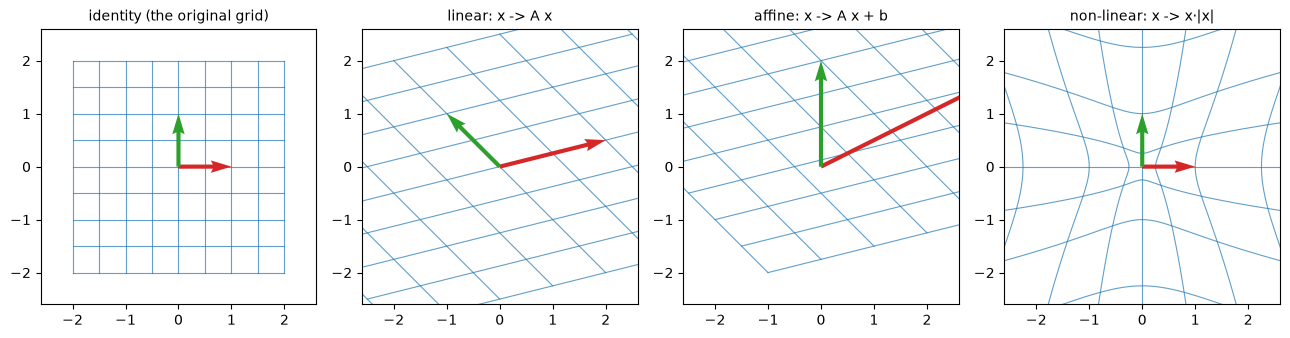

In [3]:
def grid_lines(lim=2, n=9, pts=60):
    """Horizontal and vertical lines of a square grid, as (2, pts) arrays."""
    for t in np.linspace(-lim, lim, n):
        s = np.linspace(-lim, lim, pts)
        yield np.stack([s, np.full_like(s, t)])
        yield np.stack([np.full_like(s, t), s])

def show_map(ax, f, title, lim=2.6):
    for line in grid_lines():
        out = np.stack([f(p) for p in line.T]).T
        ax.plot(out[0], out[1], color="tab:blue", lw=0.8, alpha=0.7)
    for j, col in enumerate(["tab:red", "tab:green"]):
        img = f(np.eye(2)[j])
        ax.quiver(0, 0, *img, angles="xy", scale_units="xy", scale=1,
                  color=col, width=0.015, zorder=5)
    ax.set_title(title, fontsize=10); ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
show_map(axes[0], lambda x: x,                       "identity (the original grid)")
show_map(axes[1], lambda x: A @ x,                   "linear: x -> A x")
show_map(axes[2], lambda x: A @ x + b,               "affine: x -> A x + b")
show_map(axes[3], lambda x: x * np.linalg.norm(x),   "non-linear: x -> x·|x|")
plt.tight_layout(); plt.show()

Panel 2 is stretched and skewed but still a perfect grid, and the origin has not
moved. Panel 3 is *also* a perfect grid, since affine maps preserve grids too,
but it has slid away from the origin, which is precisely the axiom it breaks.
Panel 4 is bent: lines that started straight are now curves, and no matrix can
do that.

---
# Module II — Where the Matrix Comes From

## II.a Follow the basis vectors

🧠 **The intuition.** Suppose I tell you only two things: $T$ is linear, and
where it sends $\mathbf{e}_1$ and $\mathbf{e}_2$. That is enough to compute
$T$ anywhere. Every input is built out of those two basis directions, and
linearity means the output is built out of their images by the *same recipe* —
so knowing where the basis lands determines the whole map.

📐 **The math.** Any $\mathbf{x}$ is $x_1\mathbf{e}_1 + x_2\mathbf{e}_2$, and
linearity lets you push $T$ through the combination:

$$ T(\mathbf{x}) = T(x_1\mathbf{e}_1 + x_2\mathbf{e}_2) = x_1 T(\mathbf{e}_1) + x_2 T(\mathbf{e}_2) $$

The last expression is a linear combination of the vectors $T(\mathbf{e}_j)$
with coefficients $x_j$, which, by the column view of Chapter 2, is exactly
$A\mathbf{x}$ for the matrix

$$ A = \Big[\; T(\mathbf{e}_1) \;\Big|\; T(\mathbf{e}_2) \;\Big|\; \cdots \;\Big|\; T(\mathbf{e}_n) \;\Big] $$

**The columns of a matrix are the images of the basis vectors.** That single
sentence is the bridge between "linear transformation" (a concept) and "matrix"
(a table of numbers), and it makes matrices readable: to know what a matrix
does, look at where it sends $\mathbf{e}_1$ and $\mathbf{e}_2$.

💻 **The code.** Recover the matrix from the function, then check it.

In [4]:
def matrix_of(T, dim_in):
    """The matrix of a linear map: apply T to each basis vector, stack as columns."""
    return np.column_stack([T(e) for e in np.eye(dim_in)])

def T_mystery(x):
    """Some linear map, defined without ever mentioning a matrix."""
    return np.array([3 * x[0] - x[1], x[0] + 2 * x[1], -x[1]])

M = matrix_of(T_mystery, 2)
print("recovered matrix (columns = images of e1, e2):\n", M)
print("\nT(e1) =", T_mystery(np.array([1.0, 0])), " -> first column")
print("T(e2) =", T_mystery(np.array([0, 1.0])), " -> second column")

x = rng.normal(size=2)
print("\nrandom x:", np.round(x, 3))
print("T(x) =", np.round(T_mystery(x), 3))
print("M x  =", np.round(M @ x, 3))
print("agree on 1000 random vectors:",
      all(np.allclose(T_mystery(v), M @ v) for v in rng.normal(size=(1000, 2))))

recovered matrix (columns = images of e1, e2):
 [[ 3. -1.]
 [ 1.  2.]
 [-0. -1.]]

T(e1) = [ 3.  1. -0.]  -> first column
T(e2) = [-1.  2. -1.]  -> second column

random x: [ 0.225 -0.053]
T(x) = [0.729 0.118 0.053]
M x  = [0.729 0.118 0.053]
agree on 1000 random vectors: True


Note the shape. $T$ maps $\mathbb{R}^2 \to \mathbb{R}^3$, so $M$ is $3 \times 2$:
**two columns because there are two inputs, three rows because each image lands
in $\mathbb{R}^3$.** The shape of a matrix is a statement about which spaces it
connects.

## II.b The same idea on a space with no arrows

🧠 **The intuition.** Nothing above used the fact that vectors were arrows. So
take a vector space of *polynomials*, and a transformation you have known since
calculus, differentiation, and build its matrix.

📐 **The math.** On $\mathcal{P}_3$ (degree $\le 3$) with basis $\{1, x, x^2,
x^3\}$, differentiation is linear: $(p+q)' = p' + q'$ and $(cp)' = cp'$. Those
are two of the first rules you ever learned about derivatives, and their real
name is *"$d/dx$ is a linear operator"*. So it has a matrix, a $4 \times 4$
table, once we agree on a basis.

💻 **The code.** Represent a polynomial by its coefficient vector, exactly as in
Chapter 1.

In [5]:
def differentiate(coeffs):
    """d/dx on a polynomial given by coefficients [a0, a1, a2, a3] (a0 + a1 x + ...)."""
    out = np.zeros_like(coeffs)
    for i in range(1, len(coeffs)):
        out[i - 1] = i * coeffs[i]          # d/dx of a_i x^i is i a_i x^(i-1)
    return out

is_linear(differentiate, 4, name="d/dx on P_3")

D = matrix_of(differentiate, 4)
print("\nthe matrix of d/dx in the basis {1, x, x^2, x^3}:\n", D)

p = np.array([5.0, 3.0, -2.0, 1.0])         # 5 + 3x - 2x^2 + x^3
print("\np      =", p, " ->  5 + 3x - 2x^2 + x^3")
print("D @ p  =", D @ p, " ->  3 - 4x + 3x^2      (correct by hand)")

d/dx on P_3                        additive: yes   homogeneous: yes   T(0) = 0: yes   -> LINEAR

the matrix of d/dx in the basis {1, x, x^2, x^3}:
 [[0. 1. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 3.]
 [0. 0. 0. 0.]]

p      = [ 5.  3. -2.  1.]  ->  5 + 3x - 2x^2 + x^3
D @ p  = [ 3. -4.  3.  0.]  ->  3 - 4x + 3x^2      (correct by hand)


A calculus operation is now a matrix multiplication, and facts about the
operation become facts about the matrix. Differentiate a cubic four times and
you get zero, so $D^4$ must be the zero matrix; the constant polynomial has zero
derivative, so $D$ must be singular. Both are visible in the numbers.

In [6]:
print("D^2:\n", np.linalg.matrix_power(D, 2))
print("\nD^4 is the zero matrix:", np.allclose(np.linalg.matrix_power(D, 4), 0))
print("rank of D:", np.linalg.matrix_rank(D), "of 4  -> not invertible")
const_poly = np.array([1.0, 0.0, 0.0, 0.0])          # the polynomial p(x) = 1
print("D @", const_poly, "=", D @ const_poly, " -> the constant polynomial is destroyed")
print("\nIntegration cannot be its inverse: the constant of integration is exactly")
print("the information D destroyed. Chapter 5 calls that lost direction the null space.")

D^2:
 [[0. 0. 2. 0.]
 [0. 0. 0. 6.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

D^4 is the zero matrix: True
rank of D: 3 of 4  -> not invertible
D @ [1. 0. 0. 0.] = [0. 0. 0. 0.]  -> the constant polynomial is destroyed

Integration cannot be its inverse: the constant of integration is exactly
the information D destroyed. Chapter 5 calls that lost direction the null space.


**The matrix depends on the basis.** $D$ above is the matrix of $d/dx$ *in the
basis $\{1, x, x^2, x^3\}$*. Choose a different basis for $\mathcal{P}_3$ and
the same operation gets a different table of numbers. The transformation is the
thing that exists; the matrix is its description in a chosen coordinate system,
the same distinction Chapter 3 drew for vectors. Chapter 8 exploits it
ruthlessly, by hunting for the basis in which a given transformation has the
simplest possible matrix.

---
# Module III — The 2×2 Zoo

🧠 **The intuition.** With "the columns are where the basis vectors land", you
can read a $2 \times 2$ matrix like a sentence. Each of the maps below is
something you can describe in words, and the numbers say the same thing.

📐 **The math.** The standard cast:

$$ R_\theta = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix},
\quad S = \begin{bmatrix} 2 & 0 \\ 0 & 0.5 \end{bmatrix},
\quad H = \begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix},
\quad F = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix},
\quad P = \begin{bmatrix} 1 & 0 \\ 0 & 0 \end{bmatrix} $$

rotation, scaling, shear, reflection, projection.

💻 **The code.** Each panel shows the transformed grid, the images of
$\mathbf{e}_1$ (red) and $\mathbf{e}_2$ (green), which are the columns, and the
unit square carried along with them.

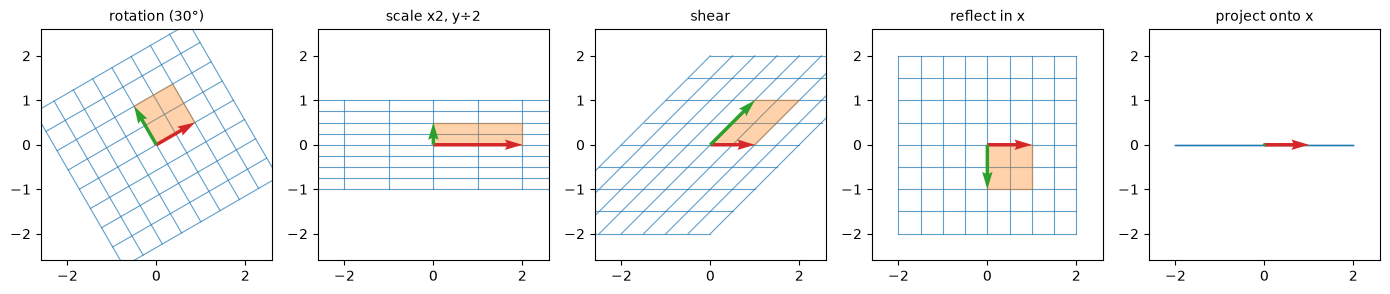

rotation (30°)   e1 -> [0.866 0.5  ]   e2 -> [-0.5    0.866]
scale x2, y÷2    e1 -> [2. 0.]   e2 -> [0.  0.5]
shear            e1 -> [1. 0.]   e2 -> [1. 1.]
reflect in x     e1 -> [1. 0.]   e2 -> [ 0. -1.]
project onto x   e1 -> [1. 0.]   e2 -> [0. 0.]


In [7]:
theta = np.pi / 6
ZOO = {
    "rotation (30°)":  np.array([[np.cos(theta), -np.sin(theta)],
                                 [np.sin(theta),  np.cos(theta)]]),
    "scale x2, y÷2":   np.array([[2.0, 0.0], [0.0, 0.5]]),
    "shear":           np.array([[1.0, 1.0], [0.0, 1.0]]),
    "reflect in x":    np.array([[1.0, 0.0], [0.0, -1.0]]),
    "project onto x":  np.array([[1.0, 0.0], [0.0, 0.0]]),
}

square = np.array([[0, 1, 1, 0, 0], [0, 0, 1, 1, 0]])      # the unit square

fig, axes = plt.subplots(1, len(ZOO), figsize=(14, 3.2))
for ax, (name, Mz) in zip(axes, ZOO.items()):
    show_map(ax, lambda x, Mz=Mz: Mz @ x, name)
    out = Mz @ square
    ax.fill(out[0], out[1], color="tab:orange", alpha=0.35, zorder=4)
plt.tight_layout(); plt.show()

for name, Mz in ZOO.items():
    print(f"{name:<16} e1 -> {Mz[:, 0]}   e2 -> {Mz[:, 1]}")

Read the last panel carefully: the **projection** flattens the whole plane onto
a line. Two dimensions in, one dimension out, so information is destroyed and no
matrix can undo it, because infinitely many input points landed on each output
point. The orange square has become a segment of zero area.

That collapse is not an edge case; it is the single most important behavioural
distinction a square matrix has. Chapter 6 measures it with the **determinant**
(the area scale factor, zero exactly when the map collapses), and Chapter 5
identifies precisely which directions get crushed.

---
# Module IV — Composition Is Matrix Multiplication

## IV.a Why the definition of $AB$ is what it is

🧠 **The intuition.** Do one transformation, then another. The result is again
linear (check: it respects both operations, because each step does), so it too
has a matrix. Matrix multiplication is *defined* to be exactly that matrix, and
the strange row-times-column rule exists to make composition work.

📐 **The math.** For $T_A(\mathbf{x}) = A\mathbf{x}$ and $T_B(\mathbf{x}) =
B\mathbf{x}$,

$$ (T_A \circ T_B)(\mathbf{x}) = A(B\mathbf{x}) = (AB)\mathbf{x} $$

$B$ acts first. **Composition reads right to left**, like $f(g(x))$, which is a
constant source of sign and order errors, and the reason the shape rule is
$(m \times k)(k \times n)$: the inner dimensions are the intermediate space both
maps must agree on.

💻 **The code.**

In [8]:
R = ZOO["rotation (30°)"]
H = ZOO["shear"]
x = rng.normal(size=2)

print("A(Bx)  (transform, then transform again):", np.round(R @ (H @ x), 4))
print("(AB)x  (multiply the matrices first):    ", np.round((R @ H) @ x, 4))

# associativity: (AB)C = A(BC), on random matrices
trials = []
for _ in range(100):
    P, Q, S = (rng.normal(size=(3, 3)) for _ in range(3))
    trials.append(np.allclose((P @ Q) @ S, P @ (Q @ S)))
print("\n(AB)C = A(BC) in all 100 random trials:", all(trials))

# rotations compose by adding angles: the matrices know trigonometry
def rot(t):
    return np.array([[np.cos(t), -np.sin(t)], [np.sin(t), np.cos(t)]])

print("\nR(0.3) @ R(0.4) == R(0.7):", np.allclose(rot(0.3) @ rot(0.4), rot(0.7)))
print("(the angle-addition formulas for sin and cos are this matrix identity)")

A(Bx)  (transform, then transform again): [-0.352 -2.372]
(AB)x  (multiply the matrices first):     [-0.352 -2.372]

(AB)C = A(BC) in all 100 random trials: True

R(0.3) @ R(0.4) == R(0.7): True
(the angle-addition formulas for sin and cos are this matrix identity)


## IV.b Order matters, and here is what it looks like

🧠 **The intuition.** "Rotate, then shear" and "shear, then rotate" are
different physical operations, so they must have different matrices. Matrix
multiplication is **not commutative**, and unlike most algebraic warnings this
one has a picture.

📐 **The math.** Composition is multiplication in right-to-left order, so
"rotate, then shear" is $HR$ and "shear, then rotate" is $RH$, and in general

$$ AB \neq BA $$

Two products of the same matrices, two different maps. The quickest witness is
a single column: if $HR$ and $RH$ send $\mathbf{e}_1$ to different places, they
are different matrices, full stop.

💻 **The code.** Three panels: the untouched grid, then $HR$, then $RH$. Watch
where the orange square lands in each, and check the printed norm of $HR - RH$,
which would be zero if the order did not matter.

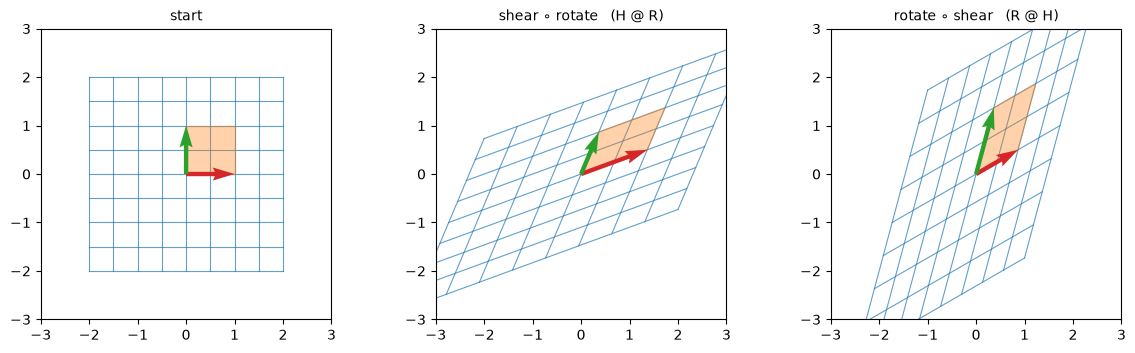

H @ R =
 [[1.366 0.366]
 [0.5   0.866]]
R @ H =
 [[0.866 0.366]
 [0.5   1.366]]

difference: ||HR - RH|| = 0.7071  (zero would mean they commute)
e1 lands at [1.366 0.5  ] one way and [0.866 0.5  ] the other


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
show_map(axes[0], lambda p: p, "start", lim=3)
show_map(axes[1], lambda p: (H @ R) @ p, "shear ∘ rotate   (H @ R)", lim=3)
show_map(axes[2], lambda p: (R @ H) @ p, "rotate ∘ shear   (R @ H)", lim=3)
for ax, Mz in zip(axes, [np.eye(2), H @ R, R @ H]):
    out = Mz @ square
    ax.fill(out[0], out[1], color="tab:orange", alpha=0.35, zorder=4)
plt.tight_layout(); plt.show()

print("H @ R =\n", H @ R)
print("R @ H =\n", R @ H)
print(f"\ndifference: ||HR - RH|| = {np.linalg.norm(H @ R - R @ H):.4f}  (zero would mean they commute)")
print("e1 lands at", np.round((H @ R)[:, 0], 3), "one way and", np.round((R @ H)[:, 0], 3), "the other")

Some pairs *do* commute, including two rotations, any matrix with the identity,
and a matrix with itself, and when they do it is telling you something
structural. Chapter 8 finds the deepest example: a matrix always commutes with
anything built from its own eigenvectors.

---
# Module V — Two Practical Consequences

## V.a Transforming a real image

🧠 **The intuition.** Every map in the zoo has so far acted on an anonymous
grid of points. But a picture is a grid of points too: each pixel sits at a
position, and positions are vectors, so anything that moves vectors moves
pictures. This is the chapter's payoff — the same matrices that rotated and
sheared graph paper will now rotate and shear a photograph of a digit.

💻 **The code.** A grayscale image is a function from pixel coordinates to
brightness. To apply a matrix $A$ to the *picture*, take each output pixel, map
it **backwards** through $A^{-1}$ to find where it came from, and copy that
brightness. (Going forwards leaves holes: the images of integer pixels are not
integers.)

/home/mujtaba/venvs/datasci/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


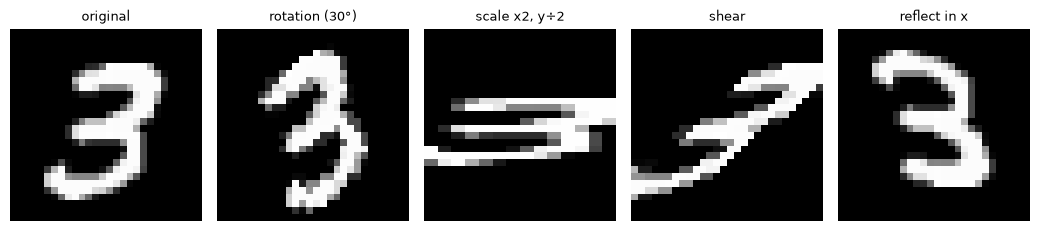

In [10]:
from datasets import load_dataset

mnist = load_dataset("ylecun/mnist")
IMG_INDEX = 7          # <- knob: which MNIST image to warp
digit = np.array(mnist["train"][IMG_INDEX]["image"], dtype=np.float64) / 255.0

def warp(image, Amat):
    """Apply the linear map A to an image, about its centre, by inverse mapping."""
    h, w = image.shape
    rows, cols = np.mgrid[0:h, 0:w]
    cx, cy = (w - 1) / 2, (h - 1) / 2
    # pixel (row, col) -> maths coordinates (x right, y up), centred
    coords = np.stack([cols.ravel() - cx, -(rows.ravel() - cy)])
    src = np.linalg.solve(Amat, coords)                   # where each output pixel came from
    src_col = np.rint(src[0] + cx).astype(int)
    src_row = np.rint(-src[1] + cy).astype(int)
    inside = (src_row >= 0) & (src_row < h) & (src_col >= 0) & (src_col < w)
    out = np.zeros(h * w)
    out[inside] = image[src_row[inside], src_col[inside]]
    return out.reshape(h, w)

shows = [("original", np.eye(2))] + [(k, v) for k, v in ZOO.items() if k != "project onto x"]
fig, axes = plt.subplots(1, len(shows), figsize=(2.1 * len(shows), 2.6))
for ax, (name, Mz) in zip(axes, shows):
    ax.imshow(warp(digit, Mz), cmap="gray"); ax.set_title(name, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

Same five matrices, now acting on a picture instead of a grid. (The projection is
left out because it maps the image to a single line, which reveals nothing
photogenic, though it is the same collapse you saw in Module III.)

## V.b Making translation linear: homogeneous coordinates

🧠 **The intuition.** Module I disqualified translation, $\mathbf{x} \mapsto
\mathbf{x} + \mathbf{b}$, because it moves the origin. That is inconvenient:
graphics pipelines, robotics, and geometry all need to *move* things, and would
rather not leave the comfort of matrix multiplication to do it.

The trick is to **add a dimension**. Represent the 2-D point $(x, y)$ as the 3-D
point $(x, y, 1)$. In that larger space, translation *is* linear: it is a shear
along the new axis, and shears are perfectly respectable linear maps.

📐 **The math.**

$$ \begin{bmatrix} A & \mathbf{b} \\ \mathbf{0}^\top & 1 \end{bmatrix}
\begin{bmatrix} \mathbf{x} \\ 1 \end{bmatrix}
= \begin{bmatrix} A\mathbf{x} + \mathbf{b} \\ 1 \end{bmatrix} $$

An affine map in $\mathbb{R}^n$ is a linear map in $\mathbb{R}^{n+1}$, restricted
to the slice where the last coordinate is 1. This is why 3-D graphics APIs use
$4 \times 4$ matrices for three-dimensional scenes.

💻 **The code.**

the 3x3 matrix doing a 2-D rotation AND a translation:
 [[ 0.866 -0.5    2.   ]
 [ 0.5    0.866 -1.   ]
 [ 0.     0.     1.   ]]

matches the affine formula A x + b: True
last row of the lifted output is all ones: True


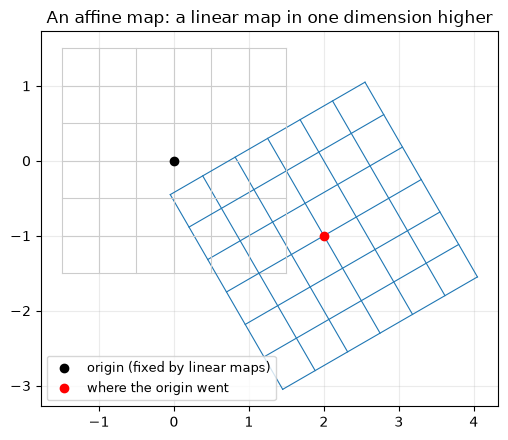

In [11]:
def homogeneous(Amat, bvec):
    """Pack a linear map A and a translation b into one (n+1)x(n+1) matrix."""
    n = Amat.shape[0]
    Mh = np.eye(n + 1)
    Mh[:n, :n] = Amat
    Mh[:n, n] = bvec
    return Mh

Mh = homogeneous(R, np.array([2.0, -1.0]))          # rotate 30°, then translate
print("the 3x3 matrix doing a 2-D rotation AND a translation:\n", Mh)

pts = rng.normal(size=(2, 6))
lifted = np.vstack([pts, np.ones(6)])                # (x, y) -> (x, y, 1)
out = (Mh @ lifted)[:2]                              # transform, then drop the extra 1

print("\nmatches the affine formula A x + b:", np.allclose(out, R @ pts + np.array([[2.0], [-1.0]])))
print("last row of the lifted output is all ones:", np.allclose((Mh @ lifted)[2], 1))

fig, ax = plt.subplots(figsize=(6, 4.5))
for line in grid_lines(lim=1.5, n=7):
    lift = np.vstack([line, np.ones(line.shape[1])])
    o = (Mh @ lift)[:2]
    ax.plot(line[0], line[1], color="0.8", lw=0.8)
    ax.plot(o[0], o[1], color="tab:blue", lw=0.8)
ax.plot(0, 0, "ko", ms=6, label="origin (fixed by linear maps)")
ax.plot(2, -1, "ro", ms=6, label="where the origin went")
ax.set_aspect("equal"); ax.legend(fontsize=9); ax.grid(alpha=0.25)
ax.set_title("An affine map: a linear map in one dimension higher")
plt.tight_layout(); plt.show()

---
# Wrap-Up

| You built | The transferable lesson |
|---|---|
| `is_linear` on six functions | Two conditions, both required; $T(\mathbf{0}) = \mathbf{0}$ is the fast disqualifier |
| Transformed grids | Linear maps keep the grid a grid: rotate, stretch, shear, flatten, but never bend |
| `matrix_of(T)` | **The columns of a matrix are the images of the basis vectors.** Every matrix is that sentence |
| The $4\times4$ matrix of $d/dx$ | "Matrix" is not about arrows; any linear map on any vector space has one, once you fix a basis |
| $D^4 = 0$, $\text{rank}(D) = 3$ | Properties of the operation become properties of its matrix, and back again |
| The 2×2 zoo, read off the columns | You can look at a small matrix and say what it does, without computing anything |
| The projection squashing the square | Collapse is the crucial behaviour: Chapter 6 measures it, Chapter 5 locates it |
| $HR \neq RH$, with pictures | Matrix multiplication is composition, and composition has an order |
| Warping a digit; homogeneous coordinates | Affine means linear one dimension up, the trick behind every graphics pipeline |

**Where the course goes from here.** A matrix is a transformation. Which means
the equation

$$ A\mathbf{x} = \mathbf{b} $$

is a *question about a transformation*: which input does $A$ send to
$\mathbf{b}$? Read that way, the three possible answers (no solution, exactly
one, infinitely many) stop being algebraic accidents and become geometric
facts about the map.

Chapter 5 answers it in general, by building elimination from scratch and
locating the two subspaces that decide everything: what the map can **reach**,
and what it **destroys**.